# 07. Comparación entre región frontal y anillo completo

Este notebook responde una pregunta práctica relevante para el uso de pseudo-LiDAR en SLAM:

**¿conviene registrar utilizando todo el pseudo-anillo o únicamente la parte más fiable?**

Para ello se comparan cuatro subconjuntos:
- `all`,
- `front`,
- `front_left`,
- `front_right`.


In [1]:
from pathlib import Path
import json
import subprocess

import matplotlib.pyplot as plt


In [2]:
ROOT = Path('/home/clara/ml-depth-pro/slam_readiness_nuscenes')
RUN_SUMMARY = ROOT / 'outputs' / 'scene-0061' / 'run_summary.json'
SCRIPT_PATH = ROOT / 'scripts' / 'compare_registration_subsets.py'


## Significado de cada subconjunto

- `all`: utiliza todo el pseudo-anillo.
- `front`: utiliza únicamente la región frontal, previamente identificada como la más estable.
- `front_left`: combina la zona frontal con el lateral izquierdo.
- `front_right`: combina la zona frontal con el lateral derecho.

Esta comparación permite estudiar si una selección más restrictiva, pero potencialmente más fiable, mejora el registro temporal.


In [3]:
cmd = [
    'python',
    str(SCRIPT_PATH),
    '--run-summary', str(RUN_SUMMARY),
    '--dataroot', '/home/clara/datasets/nuscenes',
    '--version', 'v1.0-mini',
]
print(' '.join(cmd))
result = subprocess.run(cmd, capture_output=True, text=True)
print(result.stdout)
print(result.stderr)
print('returncode:', result.returncode)


python /home/clara/ml-depth-pro/slam_readiness_nuscenes/scripts/compare_registration_subsets.py --run-summary /home/clara/ml-depth-pro/slam_readiness_nuscenes/outputs/scene-0061/run_summary.json --dataroot /home/clara/datasets/nuscenes --version v1.0-mini
/home/clara/ml-depth-pro/slam_readiness_nuscenes/outputs/scene-0061/subset_registration_comparison.json
{
  "all": {
    "translation_error_mean_m": 2.1787956239681563,
    "rotation_error_mean_deg": 3.594470517746576,
    "fitness_mean": 0.7991450457046032,
    "num_valid_pairs": 4
  },
  "front": {
    "translation_error_mean_m": 1.905902677794431,
    "rotation_error_mean_deg": 2.3303987058296873,
    "fitness_mean": 0.7518827944175293,
    "num_valid_pairs": 4
  },
  "front_left": {
    "translation_error_mean_m": 1.952608070109376,
    "rotation_error_mean_deg": 2.677978091848993,
    "fitness_mean": 0.7634236709577422,
    "num_valid_pairs": 4
  },
  "front_right": {
    "translation_error_mean_m": 2.5396937542362217,
    "rotat

In [4]:
comparison_path = ROOT / 'outputs' / 'scene-0061' / 'subset_registration_comparison.json'
comparison = json.loads(comparison_path.read_text())
comparison['aggregate']


{'all': {'translation_error_mean_m': 2.1787956239681563,
  'rotation_error_mean_deg': 3.594470517746576,
  'fitness_mean': 0.7991450457046032,
  'num_valid_pairs': 4},
 'front': {'translation_error_mean_m': 1.905902677794431,
  'rotation_error_mean_deg': 2.3303987058296873,
  'fitness_mean': 0.7518827944175293,
  'num_valid_pairs': 4},
 'front_left': {'translation_error_mean_m': 1.952608070109376,
  'rotation_error_mean_deg': 2.677978091848993,
  'fitness_mean': 0.7634236709577422,
  'num_valid_pairs': 4},
 'front_right': {'translation_error_mean_m': 2.5396937542362217,
  'rotation_error_mean_deg': 2.7746391471370764,
  'fitness_mean': 0.8010933376947806,
  'num_valid_pairs': 4}}

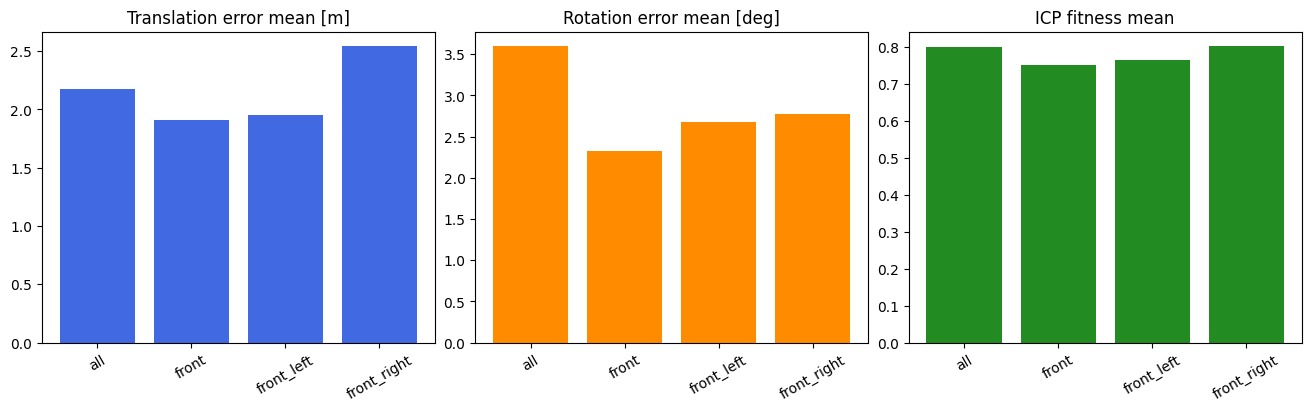

In [5]:
subsets = ['all', 'front', 'front_left', 'front_right']
trans_errors = [comparison['aggregate'][s]['translation_error_mean_m'] if comparison['aggregate'][s] else None for s in subsets]
rot_errors = [comparison['aggregate'][s]['rotation_error_mean_deg'] if comparison['aggregate'][s] else None for s in subsets]
fitness = [comparison['aggregate'][s]['fitness_mean'] if comparison['aggregate'][s] else None for s in subsets]

fig, axes = plt.subplots(1, 3, figsize=(13, 4), constrained_layout=True)
axes[0].bar(subsets, trans_errors, color='royalblue')
axes[0].set_title('Translation error mean [m]')

axes[1].bar(subsets, rot_errors, color='darkorange')
axes[1].set_title('Rotation error mean [deg]')

axes[2].bar(subsets, fitness, color='forestgreen')
axes[2].set_title('ICP fitness mean')

for ax in axes:
    ax.tick_params(axis='x', rotation=30)

plt.show()


## Criterio de interpretación

- Si `front` mejora con respecto a `all`, ello indicará que no conviene utilizar todo el anillo para el registro.
- Si `front_left` supera a `front_right`, se reforzará la hipótesis de que el lado derecho introduce más ruido.
- Si `all` sigue siendo la mejor opción, entonces el problema no residirá en la mezcla de regiones, sino en la calidad general de la pseudo-LiDAR.
